In [1]:
import datetime as dt
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
t0 = '2025-12-10/21:48:15'
tf = '2025-12-10/21:49:15'
sc = '2'

In [3]:
from lib.ACE.ace_data_loading import *
from lib.ACE.ace_plotting import *
from lib.ACE.ace_analysis import * 
# Load ACE L2 data for December 10, 2025 21:48:15 - 21:49:15 UT
ace_l2 = ACE_L2(t0,tf,sc)
ace_l2_data = ace_l2.read_data()
# Load ACE L3 data for December 10, 2025 21:48:15 - 21:49:15 UT
ace_l3 = ACE_L3(t0,tf,sc)
ace_l3_data = ace_l3.read_data()

https://tracers-portal.physics.uiowa.edu/L2/TS2/2025/12/10

C:\Users\shndrsn\tracers_py_load/data/TS2/ACE/l2/2025/12/ts2_l2_ace_def_20251210_v1.1.0.cdf
https://tracers-portal.physics.uiowa.edu/L3/TS2/2025/12/10

C:\Users\shndrsn\tracers_py_load/data/TS2/ACE/l3/2025/12/ts2_l3_ace_pitch-angle-dist_20251210_v1.2.0.cdf


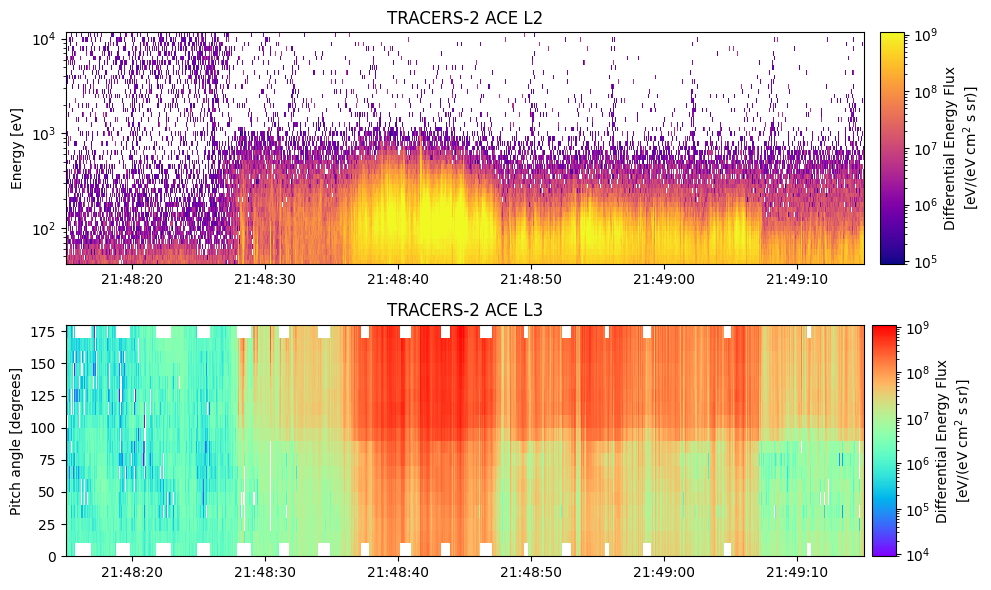

In [4]:
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))
# Plot ACE L2 data -- default is anode-averaged energy spectrogram in units of differential energy flux
ax[0] = plot_ace_l2(ace_l2_data, cmap='plasma', zlim=[1e5,1e9], title='TRACERS-2 ACE L2',ax=ax[0])
# Plot ACE L3 data -- default is energy-averaged pitch angle spectrogram in units of differential energy flux
ax[1] = plot_ace_l3(ace_l3_data, cmap='rainbow', zlim=[1e4,1e9], title='TRACERS-2 ACE L3', ax=ax[1])
plt.tight_layout()
plt.show()

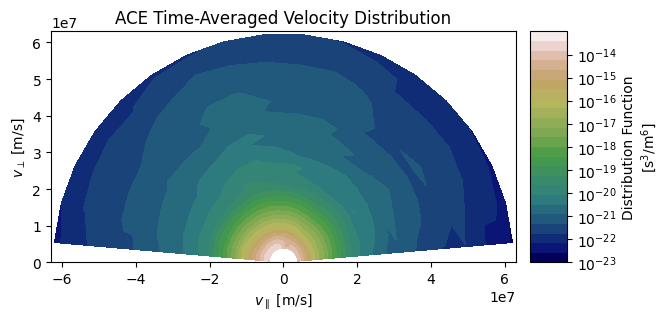

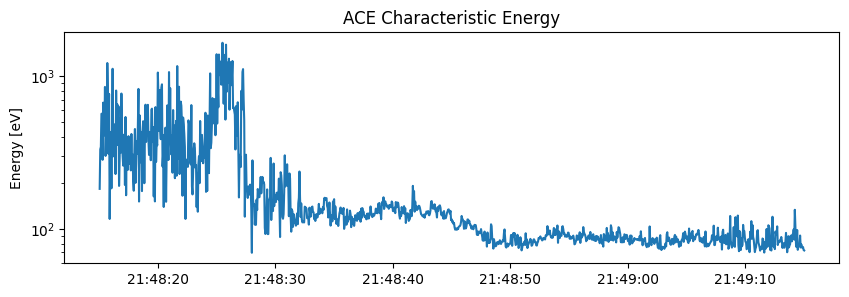

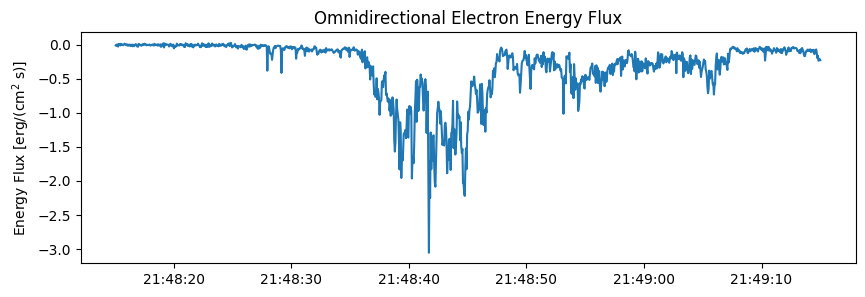

In [5]:
# Calculates the characteristic energy, which is useful particularly for 
# periods with inverted V signatures.
char_e = get_characteristic_energies(ace_l2_data)

# Calculates the energy flux over all pitch angles. 
# Optional inputs include keywords that limit the subset of angles to calculate eflux over, 
# the energy range you wish to calculate energy flux over, and if you'd like to replace negative
# differential energy fluxes with values of 0.
# This particular ROI is in the southern hemisphere, so pitch angles between 90 - 180 indicate
# ** precipitating** fluxes. The cos(pa) term makes this negative in the south, which is what 
# is happening in the plot.
omni_eflux = calculate_energy_flux(ace_l3_data,replace_negatives=True)

# Plot velocity distribution using ACE L3 data. Option to average or sum over time.
ax = plot_epad_snapshot(ace_l3_data, time_avg=True, units='df', cmap='gist_earth', n_levels=25)
plt.show()

plt.figure(figsize=(10,3))
plt.plot(ace_l2_data['DT'], char_e)
plt.yscale('log')
plt.ylabel('Energy [eV]')
plt.title('ACE Characteristic Energy')
plt.show()

plt.figure(figsize=(10,3))
plt.plot(ace_l3_data['DT'], omni_eflux)
plt.ylabel('Energy Flux [erg/(cm$^2$ s)]')
plt.title('Omnidirectional Electron Energy Flux')
plt.show()

In [6]:
from lib.ACI.aci_data_loading import *
from lib.ACI.aci_plotting import *
t0 = '2025-12-10/21:48:15'
tf = '2025-12-10/21:51:00'
# Load TS1 ACI L2 data for December 10, 2025 21:48:15 - 21:49:15 UT
aci_l2_ts1 = ACI_L2(t0,tf,'1')
aci_l2_data_ts1 = aci_l2_ts1.read_data()

# Load TS1 ACI L2 data for December 10, 2025 21:48:15 - 21:49:15 UT
aci_l2_ts2 = ACI_L2(t0,tf,'2')
aci_l2_data_ts2 = aci_l2_ts2.read_data()

https://tracers-portal.physics.uiowa.edu/L2/TS1/2025/12/10

C:\Users\shndrsn\tracers_py_load/data/TS1/ACI/l2/2025/12/ts1_l2_aci_ipd_20251210_v1.0.2.cdf
https://tracers-portal.physics.uiowa.edu/L2/TS2/2025/12/10

C:\Users\shndrsn\tracers_py_load/data/TS2/ACI/l2/2025/12/ts2_l2_aci_ipd_20251210_v1.0.1.cdf


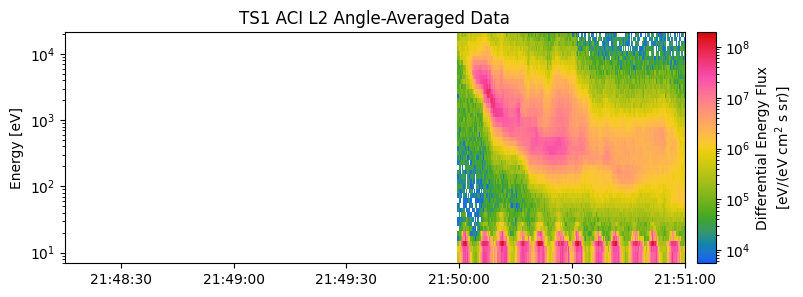

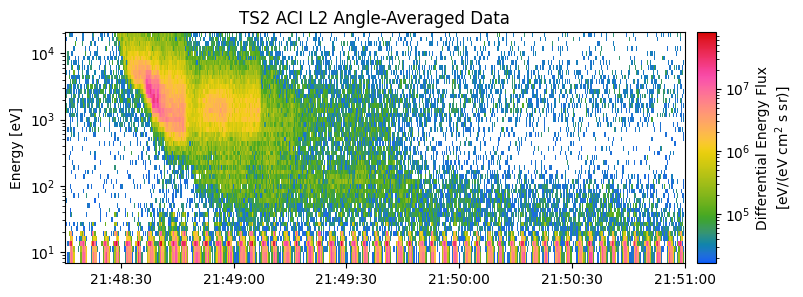

In [7]:
# Plot ACI L2 data -- default is anode-averaged energy spectrogram in units of differential energy flux
# This is an example default output for the plotting code with no keywords included.
ax = plot_aci_l2(aci_l2_data_ts1) # plotting TS1 data
plt.show()

ax = plot_aci_l2(aci_l2_data_ts2) # plotting TS2 data
plt.show()

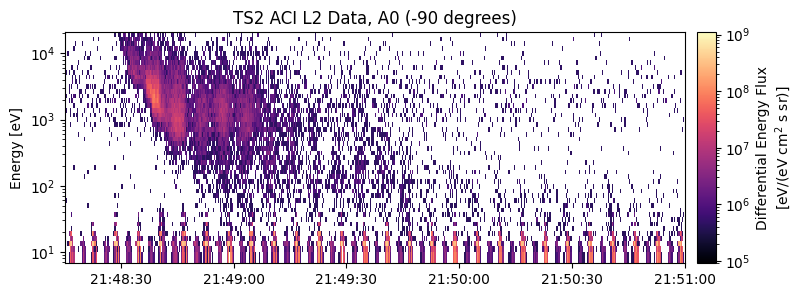

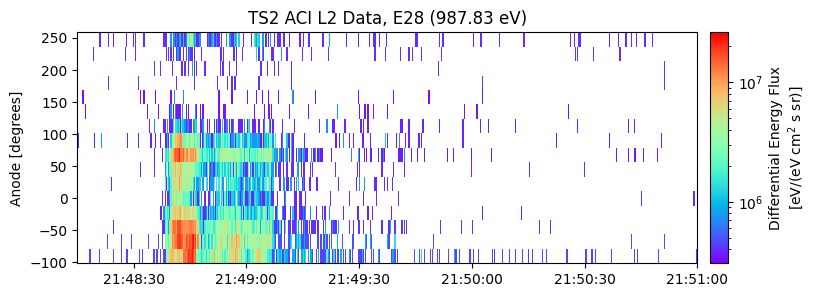

In [8]:
# Plotting zeroth anode for ACI TS2. Setting limit of color bar with zlim keyword. Choosing colormap 
# with cmap keyword input.
ax = plot_aci_l2(aci_l2_data_ts2, zlim=[1e5,1e9], cmap='magma', anode=0)
plt.show()

# Plotting the 28th energy channel using echannel keyword
ax = plot_aci_l2(aci_l2_data_ts2, cmap='rainbow', echannel=28)
plt.show()

In [9]:
from lib.MSC.msc_data_loading import *
from lib.MSC.msc_plotting import * 

# Load MSC L2 data for December 10, 2025 21:48:15 - 21:49:15 UT
# **Note: MSC data are bulky, so this can take some time!**
msc_l2 = MSC_L2(t0,tf,sc)
msc_l2_data = msc_l2.read_data()


https://tracers-portal.physics.uiowa.edu/L2/TS2/2025/12/10/ts2_l2_msc_bac_20251210_v1.1.0.cdf
C:\Users\shndrsn\tracers_py_load/data/TS2/MSC/l2/2025/12/ts2_l2_msc_bac_20251210_v1.1.0.cdf


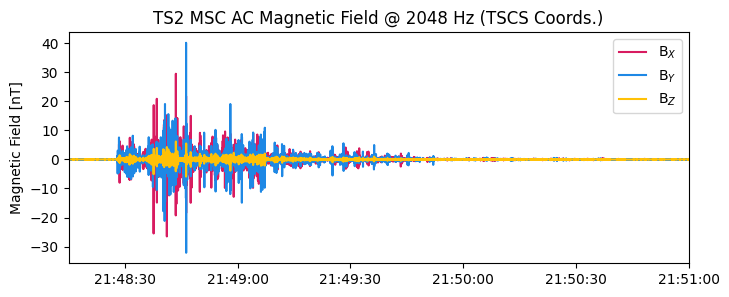

In [10]:
# Plots a time series of MSC data
ax = plot_msc_l2(msc_l2_data)
plt.show()

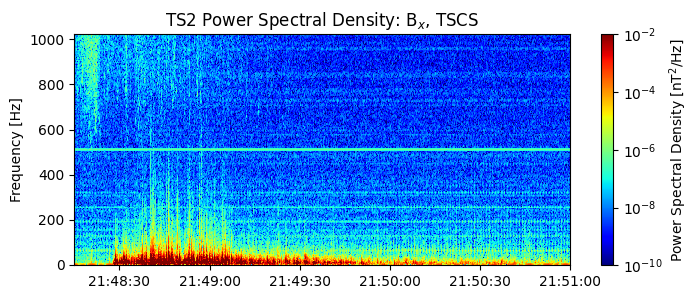

In [11]:
# Plots a time series of power spectral density derived for a given MSC axis
a = plot_msc_l2_psd(msc_l2_data, coords='tscs', component='x')
plt.show()

In [12]:
from lib.MAGIC.magic_data_loading import *
from lib.MAGIC.magic_plotting import *
t0 = '2025-09-29/08:26:00'
tf = '2025-09-29/08:27:00'
magic_l2 = MAGIC_L2(t0,tf,'2')
magic_l2_data = magic_l2.read_data()


https://tracers-portal.physics.uiowa.edu/MAGIC/TS2/L2/2025/09/

C:\Users\shndrsn\tracers_py_load/data/TS2/MAGIC/l2/2025/09/ts2_l2_magic_tsc_b_20250929_v1.2.0.cdf


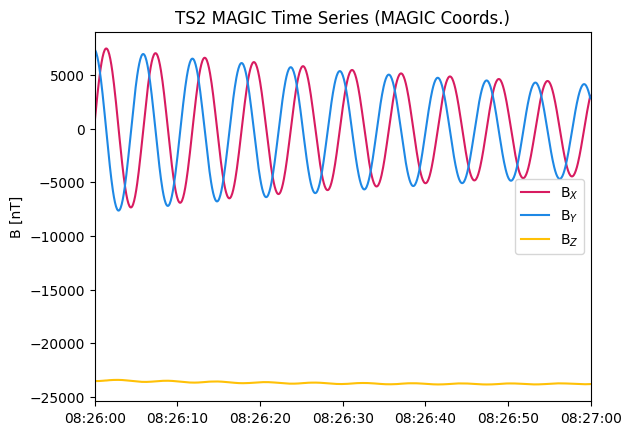

In [13]:
ax = plot_magic_ts(magic_l2_data,coords='magic')
plt.show()

In [14]:
# EFI will be updated once public data are available.
# Only team members can currently access this.
# An example calling of EFI routines can be seen below:

# from lib.EFI.efi_data_loading import *
# from lib.EFI.efi_plotting import * 

# Load EFI L2 data for December 10, 2025 21:48:15 - 21:49:15 UT
# efi_l2 = EFI_L2(t0,tf,sc)
# efi_l2_data = efi_l2.read_data(data_prod='vdc+eac+ehf',\
#                                username=username,password=password)

# EAC plot
# -- Spectrogram --
# ax = plot_efi_eac_spec(efi_l2_data,time_res='10s',cmap='magma',zlim=[1e-12,1e-9])
# -- Time Series --
# ax2 = plot_efi_eac_ts(efi_l2_data)

# EHF plot
# -- Spectrogram --
# ax = plot_efi_ehf_spec(efi_l2_data,cmap='magma',time_res='10s')
# -- Time Series -- 
# ax = plot_efi_ehf_ts(efi_data)

# VDC plot 
# -- Time Series --
# ax =  plot_efi_vdc_ts(efi_data,time_res='10s')



In [15]:
# Similar to EFI, ephemeris and attitude data (EAD) are for team members only. If you want to load 
# these files, you can call the following:

# from lib.general.ead_file_loading import *
# ead = EADload(t0,tf,sc)
# ead_data = ead.read_data(username=username,password=password)

# If you'd like to plot the TRACERS trajectory over an Earth map, you can use the
# geographic_plot function in misc_functions. This calls EAD files, so you will need
# to be a team member to access this capability.

# from lib.general.map_plotting_functions import geographic_plot
# ax = geographic_plot(t0, tf, sc, cmap='cividis', hemisphere='South', nightshade=True,\
#                    username=username, password=password)